## **Import & Setup**

In [1]:
import sys
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
import numpy as np
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares
import itertools
import torch
import torch.nn as nn
import json
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

sys.path.append('../src')
from evaluation import evaluate, print_results

all_results = {}

## **Help Functions**

In [2]:
def record(name, summary):
    all_results[name] = {
        **{f'full_{k}': v for k, v in summary['full'].items()},
        **{f'tail_{k}': v for k, v in summary.get('long_tail', {}).items()},
    }

## **Load the Train/Val/Test Data**

In [3]:
DATA = '../data'
train_matrix = pd.read_parquet(f'{DATA}/train_matrix.parquet')
full_matrix  = pd.read_parquet(f'{DATA}/interaction_matrix_raw.parquet')
test_df      = pd.read_parquet(f'{DATA}/test_pairs.parquet')
val_df       = pd.read_parquet(f'{DATA}/val_pairs.parquet')

## **Evaluate: Top-Pop**

In [4]:
# --- TopPop: score neighbourhoods by total business count in TRAINING data ---
# Non-personalised: same ranking for every NACE class.
neighborhood_popularity = train_matrix.sum(axis=0)  # Series over 48 neighbourhoods

In [5]:
def toppop_score_fn(nace):
    return neighborhood_popularity  # identical for all classes

In [6]:
# Define "head" neighbourhoods for long-tail evaluation (top 10 by popularity)
head = set(neighborhood_popularity.sort_values(ascending=False).head(10).index)

In [7]:
summary_top_pop, per_instance_top_pop = evaluate(toppop_score_fn, test_df, full_matrix, head_neighborhoods=head)
record('TopPop', summary_top_pop)

In [8]:
print_results('TopPop', summary_top_pop)

TopPop — full test set:
  HR@1: 0.2254
  NDCG@1: 0.2254
  HR@3: 0.5287
  NDCG@3: 0.4009
  HR@5: 0.7090
  NDCG@5: 0.4739
  HR@10: 0.8648
  NDCG@10: 0.5262
  (n = 244)

TopPop — long-tail subset:
  HR@1: 0.0167
  NDCG@1: 0.0167
  HR@3: 0.0500
  NDCG@3: 0.0355
  HR@5: 0.2333
  NDCG@5: 0.1086
  HR@10: 0.4500
  NDCG@10: 0.1792
  (n = 60)



## **Evaluate: Item-Item CF**

In [9]:
# Neighbourhood-neighbourhood cosine similarity from the TRAINING matrix.
# Each neighbourhood is represented by its column (its NACE-class profile).
nbhd_vectors = train_matrix.T.values            # shape (48, 306)
sim = cosine_similarity(nbhd_vectors)            # (48, 48)
sim_df = pd.DataFrame(sim, index=train_matrix.columns, columns=train_matrix.columns)

In [10]:
def itemcf_score_fn(nace):
    # score(c, :) = sim_matrix @ train[c, :]   (vectorised)
    class_vector = train_matrix.loc[nace].values        # (48,)
    scores = sim_df.values @ class_vector               # (48,)
    return pd.Series(scores, index=train_matrix.columns)

In [11]:
summary_cf, per_instance_cf = evaluate(itemcf_score_fn, test_df, full_matrix, head_neighborhoods=head)
record('ItemCF', summary_cf)

In [12]:
print_results('ItemCF', summary_cf)

ItemCF — full test set:
  HR@1: 0.2582
  NDCG@1: 0.2582
  HR@3: 0.4467
  NDCG@3: 0.3686
  HR@5: 0.5492
  NDCG@5: 0.4109
  HR@10: 0.7582
  NDCG@10: 0.4783
  (n = 244)

ItemCF — long-tail subset:
  HR@1: 0.0833
  NDCG@1: 0.0833
  HR@3: 0.2667
  NDCG@3: 0.1925
  HR@5: 0.3833
  NDCG@5: 0.2398
  HR@10: 0.5833
  NDCG@10: 0.3022
  (n = 60)



## **Evaluate: PureSVD**

In [13]:
def make_puresvd_score_fn(n_factors):
    svd = TruncatedSVD(n_components=n_factors, random_state=42)
    svd.fit(train_matrix.values)          # (306 NACE × 48 neighbourhoods)
    Q = svd.components_.T                  # (48, f) neighbourhood factors
    QQt = Q @ Q.T                          # (48, 48)
    def score_fn(nace):
        r_c = train_matrix.loc[nace].values
        return pd.Series(r_c @ QQt, index=train_matrix.columns)
    return score_fn

In [14]:
# --- Tune n_factors on the VALIDATION set ---
# Max factors = 48 (number of neighbourhoods). Try a grid below that.
factor_grid = [10, 20, 30, 40]
TUNING_METRIC = ('full', 'NDCG@10')   # same metric for every method, for fairness

val_scores = {}
for f in factor_grid:
    sfn = make_puresvd_score_fn(f)
    s_val, _ = evaluate(sfn, val_df, full_matrix, head_neighborhoods=head)
    val_scores[f] = s_val[TUNING_METRIC[0]][TUNING_METRIC[1]]
    print(f'  f={f}: val {TUNING_METRIC[1]} = {val_scores[f]:.4f}')

best_f = max(val_scores, key=val_scores.get)
print(f'Best n_factors (on validation): {best_f}')

  f=10: val NDCG@10 = 0.2613
  f=20: val NDCG@10 = 0.0846
  f=30: val NDCG@10 = 0.0533
  f=40: val NDCG@10 = 0.1185
Best n_factors (on validation): 10


In [15]:
# --- Evaluate the best config on TEST ---
best_sfn = make_puresvd_score_fn(best_f)
summary_svd, per_instance_svd = evaluate(best_sfn, test_df, full_matrix, head_neighborhoods=head)
record('PureSVD', summary_svd)

In [16]:
print_results('PureSVD', summary_svd)

PureSVD — full test set:
  HR@1: 0.0779
  NDCG@1: 0.0779
  HR@3: 0.1803
  NDCG@3: 0.1355
  HR@5: 0.2541
  NDCG@5: 0.1659
  HR@10: 0.4672
  NDCG@10: 0.2345
  (n = 244)

PureSVD — long-tail subset:
  HR@1: 0.2000
  NDCG@1: 0.2000
  HR@3: 0.4167
  NDCG@3: 0.3192
  HR@5: 0.4667
  NDCG@5: 0.3393
  HR@10: 0.6667
  NDCG@10: 0.4044
  (n = 60)



## **Evaluate: Implicit MF**

In [17]:
# implicit (>=0.5) expects a USER-item CSR matrix: users=NACE, items=neighbourhoods.
train_sparse = sp.csr_matrix(train_matrix.values.astype(np.float32))
nace_to_idx = {n: i for i, n in enumerate(train_matrix.index)}

In [18]:
def make_hu_score_fn(factors, regularization, alpha, iterations=20):
    # Manual confidence scaling: the ALS core uses c = 1 + (input value),
    # so passing alpha*count gives Hu et al.'s c = 1 + alpha*count.
    # (Done manually rather than via the `alpha=` arg, which behaves
    #  differently across implicit versions.)
    conf = (train_sparse * alpha).astype(np.float32)
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=42,
    )
    model.fit(conf, show_progress=False)

    item_factors = model.item_factors   # (48, f)
    user_factors = model.user_factors   # (306, f)
    # Some versions return GPU-backed arrays:
    if hasattr(item_factors, 'to_numpy'):
        item_factors = item_factors.to_numpy()
        user_factors = user_factors.to_numpy()

    def score_fn(nace):
        u = user_factors[nace_to_idx[nace]]      # (f,)
        return pd.Series(item_factors @ u, index=train_matrix.columns)
    return score_fn

In [19]:
# validation grid search
grid = {
    'factors': [16, 32, 48],
    'regularization': [0.01, 0.1, 1.0],
    'alpha': [1, 10, 40],
}

best = (None, -1)
for fac, reg, alp in itertools.product(grid['factors'], grid['regularization'], grid['alpha']):
    sfn = make_hu_score_fn(fac, reg, alp)
    s_val, _ = evaluate(sfn, val_df, full_matrix, head_neighborhoods=head)
    score = s_val['full']['NDCG@10']
    if score > best[1]:
        best = ((fac, reg, alp), score)

print(f'Best config: factors={best[0][0]}, reg={best[0][1]}, alpha={best[0][2]} '
      f'(val NDCG@10={best[1]:.4f})')

c:\Users\Giorgos\anaconda3\envs\machine-learning\lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Best config: factors=32, reg=1.0, alpha=1 (val NDCG@10=0.3481)


In [20]:
# Evaluate best on TEST
best_sfn = make_hu_score_fn(*best[0])
summary_hu, _ = evaluate(best_sfn, test_df, full_matrix, head_neighborhoods=head)
record('HuMF', summary_hu)

In [21]:
print_results('HuMF', summary_hu)

HuMF — full test set:
  HR@1: 0.0574
  NDCG@1: 0.0574
  HR@3: 0.2131
  NDCG@3: 0.1465
  HR@5: 0.3566
  NDCG@5: 0.2054
  HR@10: 0.5943
  NDCG@10: 0.2833
  (n = 244)

HuMF — long-tail subset:
  HR@1: 0.0667
  NDCG@1: 0.0667
  HR@3: 0.2333
  NDCG@3: 0.1609
  HR@5: 0.3333
  NDCG@5: 0.2025
  HR@10: 0.5167
  NDCG@10: 0.2634
  (n = 60)



## **Evaluate: NeuMF**

In [22]:
nace_list = train_matrix.index.tolist()
nbhd_list = train_matrix.columns.tolist()
nace_to_idx = {n: i for i, n in enumerate(nace_list)}
train_values = train_matrix.values
neg_pools = {i: np.where(train_values[i] == 0)[0] for i in range(len(nace_list))}
pos_pairs = np.array([(i, j) for i in range(len(nace_list))
                      for j in range(len(nbhd_list)) if train_values[i, j] > 0])

In [23]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, mf_dim=8, mlp_dim=16):
        super().__init__()
        self.u_gmf = nn.Embedding(n_users, mf_dim)
        self.i_gmf = nn.Embedding(n_items, mf_dim)
        self.u_mlp = nn.Embedding(n_users, mlp_dim // 2)
        self.i_mlp = nn.Embedding(n_items, mlp_dim // 2)
        self.mlp = nn.Sequential(nn.Linear(mlp_dim, mlp_dim // 2), nn.ReLU())
        self.out = nn.Linear(mf_dim + mlp_dim // 2, 1)

    def forward(self, u, i):
        gmf = self.u_gmf(u) * self.i_gmf(i)
        mlp = self.mlp(torch.cat([self.u_mlp(u), self.i_mlp(i)], dim=-1))
        return torch.sigmoid(self.out(torch.cat([gmf, mlp], dim=-1))).squeeze(-1)
    
def train_neumf(mf_dim=8, mlp_dim=16, neg_ratio=4, lr=0.01,
                epochs=50, weight_decay=1e-5, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model = NeuMF(len(nace_list), len(nbhd_list), mf_dim, mlp_dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        users, items, labels = [], [], []
        for (i, j) in pos_pairs:
            users.append(i); items.append(j); labels.append(1.0)
            pool = neg_pools[i]
            n_neg = min(neg_ratio, len(pool))
            for jn in np.random.choice(pool, size=n_neg, replace=False):
                users.append(i); items.append(int(jn)); labels.append(0.0)
        u = torch.tensor(users); it = torch.tensor(items); lab = torch.tensor(labels)
        perm = torch.randperm(len(u)); u, it, lab = u[perm], it[perm], lab[perm]
        model.train(); opt.zero_grad()
        loss = loss_fn(model(u, it), lab); loss.backward(); opt.step()
    model.eval()
    return model

In [24]:
def make_neumf_score_fn(model):
    items = torch.arange(len(nbhd_list))
    def score_fn(nace):
        u = torch.full((len(nbhd_list),), nace_to_idx[nace], dtype=torch.long)
        with torch.no_grad():
            return pd.Series(model(u, items).numpy(), index=nbhd_list)
    return score_fn

In [25]:
# validation grid search
best = (None, -1)
for mf, mlp, neg, lr in itertools.product([4, 8], [8, 16], [2, 4], [0.01, 0.005]):
    m = train_neumf(mf, mlp, neg, lr)
    s_val, _ = evaluate(make_neumf_score_fn(m), val_df, full_matrix, head_neighborhoods=head)
    if s_val['full']['NDCG@10'] > best[1]:
        best = ((mf, mlp, neg, lr), s_val['full']['NDCG@10'])

print('Best NeuMF config:', best)
m_best = train_neumf(*best[0])

Best NeuMF config: ((4, 16, 2, 0.01), 0.45353442477901384)


In [26]:
summary_ncf, _ = evaluate(make_neumf_score_fn(m_best), test_df, full_matrix, head_neighborhoods=head)
record('NeuMF', summary_ncf)

In [27]:
print_results('NeuMF', summary_ncf)

NeuMF — full test set:
  HR@1: 0.2336
  NDCG@1: 0.2336
  HR@3: 0.4672
  NDCG@3: 0.3670
  HR@5: 0.6230
  NDCG@5: 0.4314
  HR@10: 0.8279
  NDCG@10: 0.4976
  (n = 244)

NeuMF — long-tail subset:
  HR@1: 0.0667
  NDCG@1: 0.0667
  HR@3: 0.1333
  NDCG@3: 0.1022
  HR@5: 0.3000
  NDCG@5: 0.1703
  HR@10: 0.5667
  NDCG@10: 0.2580
  (n = 60)



## **Evaluate: Content-Based ML**

After looking at the evaluation results, we see that ***the introduction of LLM embeddings does NOT improve the results (!)***, therefore showing again that the main contribution of LLMs in this thesis is for ***constraint extraction*** instead of pure ranking

In [44]:
# -------------- Step 1 - Neighborhood features (numerical) -------------- 
# Keep numeric neighborhood features
nf_feat   = pd.read_parquet('../data/neighborhood_features.parquet')
_nb_cols  = list(train_matrix.columns)
_na_idx   = list(train_matrix.index)
_feat_cols = [c for c in nf_feat.columns if nf_feat[c].dtype != object]   # 24 numeric features
nf_feat   = nf_feat.loc[_nb_cols, _feat_cols]

### **Classifier 1 - Using One-Hot as NACE Representation**

In [45]:
# -------------- Step 2a - NACE category features (one-hot encoding) --------------
_div = np.array([int(n) for n in _na_idx])                # division = integer part (47.71 -> 47)
_div_levels = sorted(set(_div))
NACE_DIV = np.zeros((len(_na_idx), len(_div_levels)))
for _i, _d in enumerate(_div):
    NACE_DIV[_i, _div_levels.index(_d)] = 1.0
print(f'{len(_div_levels)} NACE divisions -> one-hot dim {NACE_DIV.shape[1]}')

75 NACE divisions -> one-hot dim 75


In [46]:
def make_content_div_score_fn():
    X = np.hstack([np.repeat(NACE_DIV, len(_nb_cols), axis=0),
                   np.tile(nf_feat.values, (len(_na_idx), 1))])
    y = (train_matrix.loc[_na_idx, _nb_cols].values.reshape(-1) > 0).astype(int)
    clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1).fit(X, y)
    proba = clf.predict_proba(X)[:, 1].reshape(len(_na_idx), len(_nb_cols))
    scores = {n: pd.Series(proba[i], index=train_matrix.columns) for i, n in enumerate(_na_idx)}
    def score_fn(nace):
        return scores[nace]
    return score_fn

In [47]:
content_div_score_fn = make_content_div_score_fn()
summary_content_div, per_instance_content_div = evaluate(content_div_score_fn, test_df, full_matrix, head_neighborhoods=head)
record('Content (division)', summary_content_div)

In [48]:

print_results('Content (division)', summary_content_div)

Content (division) — full test set:
  HR@1: 0.2377
  NDCG@1: 0.2377
  HR@3: 0.4590
  NDCG@3: 0.3682
  HR@5: 0.6475
  NDCG@5: 0.4462
  HR@10: 0.8279
  NDCG@10: 0.5048
  (n = 244)

Content (division) — long-tail subset:
  HR@1: 0.0667
  NDCG@1: 0.0667
  HR@3: 0.1667
  NDCG@3: 0.1232
  HR@5: 0.2667
  NDCG@5: 0.1648
  HR@10: 0.5000
  NDCG@10: 0.2394
  (n = 60)



### **Classifier 2 - Using Embeddings as NACE Representation**

In [49]:
# -------------- Step 2b - NACE category features (embeddgins of NACE descriptions) --------------
# Find precomputed NACE description embeddings (BGE-large, 1024-d) from the RAG pipeline (in either filepath)
_emb_path = next((p for p in [
    '../data/nace_descriptions_embeddings.json',
    '../../08. Approach - RAG/Extracted Files/NACE Description Embeddings/nace_descriptions_embeddings.json',
] if os.path.exists(p)), None)
assert _emb_path, 'NACE embeddings JSON not found — copy it into ../data/'

# Save embeddings in array
_emb_lookup = {round(float(it['nace_code']), 4): np.asarray(it['embedding'], float)
               for it in json.load(open(_emb_path))}
NACE_EMB = np.vstack([_emb_lookup[round(float(n), 4)] for n in _na_idx])   # (n_nace, 1024)

In [50]:
def make_content_score_fn(n_pca):
   
    # Apply PCA for dimensionality reduction
    emb_red = PCA(n_components=n_pca, random_state=42).fit_transform(NACE_EMB)
    
    # Create training instances (concat nace and neighborhood features)
    X = np.hstack([np.repeat(emb_red, len(_nb_cols), axis=0),       # NACE block (constant within a NACE)
                   np.tile(nf_feat.values, (len(_na_idx), 1))])     # neighbourhood block
    y = (train_matrix.loc[_na_idx, _nb_cols].values.reshape(-1) > 0).astype(int)  # held-out cells already 0
    
    # Train the classifier
    clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1).fit(X, y)
    
    # Inference the classifier
    proba = clf.predict_proba(X)[:, 1].reshape(len(_na_idx), len(_nb_cols))
    scores = {n: pd.Series(proba[i], index=train_matrix.columns) for i, n in enumerate(_na_idx)}
    def score_fn(nace):
        return scores[nace]
    return score_fn

In [51]:
# Fine the optimal PCA dimension (using the validation set)
pca_grid = [8, 16, 32, 64]
val_scores = {}
for f in pca_grid:
    sfn = make_content_score_fn(f)
    s_val, _ = evaluate(sfn, val_df, full_matrix, head_neighborhoods=head)
    val_scores[f] = s_val[TUNING_METRIC[0]][TUNING_METRIC[1]]
    print(f'  n_pca={f}: val {TUNING_METRIC[1]} = {val_scores[f]:.4f}')

best_pca = max(val_scores, key=val_scores.get)
print(f'Best n_pca (on validation): {best_pca}')

  n_pca=8: val NDCG@10 = 0.4603
  n_pca=16: val NDCG@10 = 0.4831
  n_pca=32: val NDCG@10 = 0.4857
  n_pca=64: val NDCG@10 = 0.4641
Best n_pca (on validation): 32


In [52]:
best_sfn = make_content_score_fn(best_pca)
summary_content, per_instance_content = evaluate(best_sfn, test_df, full_matrix, head_neighborhoods=head)
record('Content (emb)', summary_content)

In [53]:
print_results('Content (emb)', summary_content)

Content (emb) — full test set:
  HR@1: 0.2418
  NDCG@1: 0.2418
  HR@3: 0.4262
  NDCG@3: 0.3485
  HR@5: 0.5697
  NDCG@5: 0.4072
  HR@10: 0.8156
  NDCG@10: 0.4873
  (n = 244)

Content (emb) — long-tail subset:
  HR@1: 0.0333
  NDCG@1: 0.0333
  HR@3: 0.1333
  NDCG@3: 0.0921
  HR@5: 0.2667
  NDCG@5: 0.1451
  HR@10: 0.5500
  NDCG@10: 0.2348
  (n = 60)



## **Evaluate: Random Baseline**

This is used to demonstrate the effectiveness of the baseline methods applied for my data

In [33]:
def make_random_score_fn(seed):
    rng = np.random.default_rng(seed)
    cols = train_matrix.columns
    def score_fn(nace):
        return pd.Series(rng.random(len(cols)), index=cols)
    return score_fn

In [34]:
# Average over several random seeds
runs = [evaluate(make_random_score_fn(s), test_df, full_matrix, head_neighborhoods=head)[0]
        for s in range(5)]

In [35]:
def avg_summaries(summary_list):
    out = {'full': {}, 'long_tail': {}}
    for subset in ('full', 'long_tail'):
        for metric in summary_list[0][subset]:
            out[subset][metric] = float(np.mean([s[subset][metric] for s in summary_list]))
    out['full_n'] = summary_list[0]['full_n']
    out['long_tail_n'] = summary_list[0]['long_tail_n']
    return out

In [36]:
summary_random = avg_summaries(runs)
print_results('Random', summary_random)

Random — full test set:
  HR@1: 0.0336
  NDCG@1: 0.0336
  HR@3: 0.0820
  NDCG@3: 0.0605
  HR@5: 0.1377
  NDCG@5: 0.0833
  HR@10: 0.2541
  NDCG@10: 0.1205
  (n = 244)

Random — long-tail subset:
  HR@1: 0.0400
  NDCG@1: 0.0400
  HR@3: 0.0800
  NDCG@3: 0.0631
  HR@5: 0.1467
  NDCG@5: 0.0903
  HR@10: 0.2533
  NDCG@10: 0.1239
  (n = 60)



## **Comparison**

In [54]:
summaries = {
    'TopPop': summary_top_pop, 
    'ItemCF': summary_cf, 
    'PureSVD': summary_svd, 
    'HuMF': summary_hu,
    'NeuMF': summary_ncf,
    'Random': summary_random,
    'Content (division)': summary_content_div,
    'Content (emb)': summary_content}

In [55]:
K_VALUES = [1, 3, 5, 10]

def plot_metric(summaries, metric, subset, ax):
    for name, s in summaries.items():
        if subset not in s:
            continue
        values = [s[subset][f'{metric}@{k}'] for k in K_VALUES]
        ax.plot(K_VALUES, values, marker='o', label=name)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric}@K')
    subset_label = 'full test set' if subset == 'full' else 'long-tail subset'
    ax.set_title(f'{metric}@K — {subset_label}')
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(True, alpha=0.3)

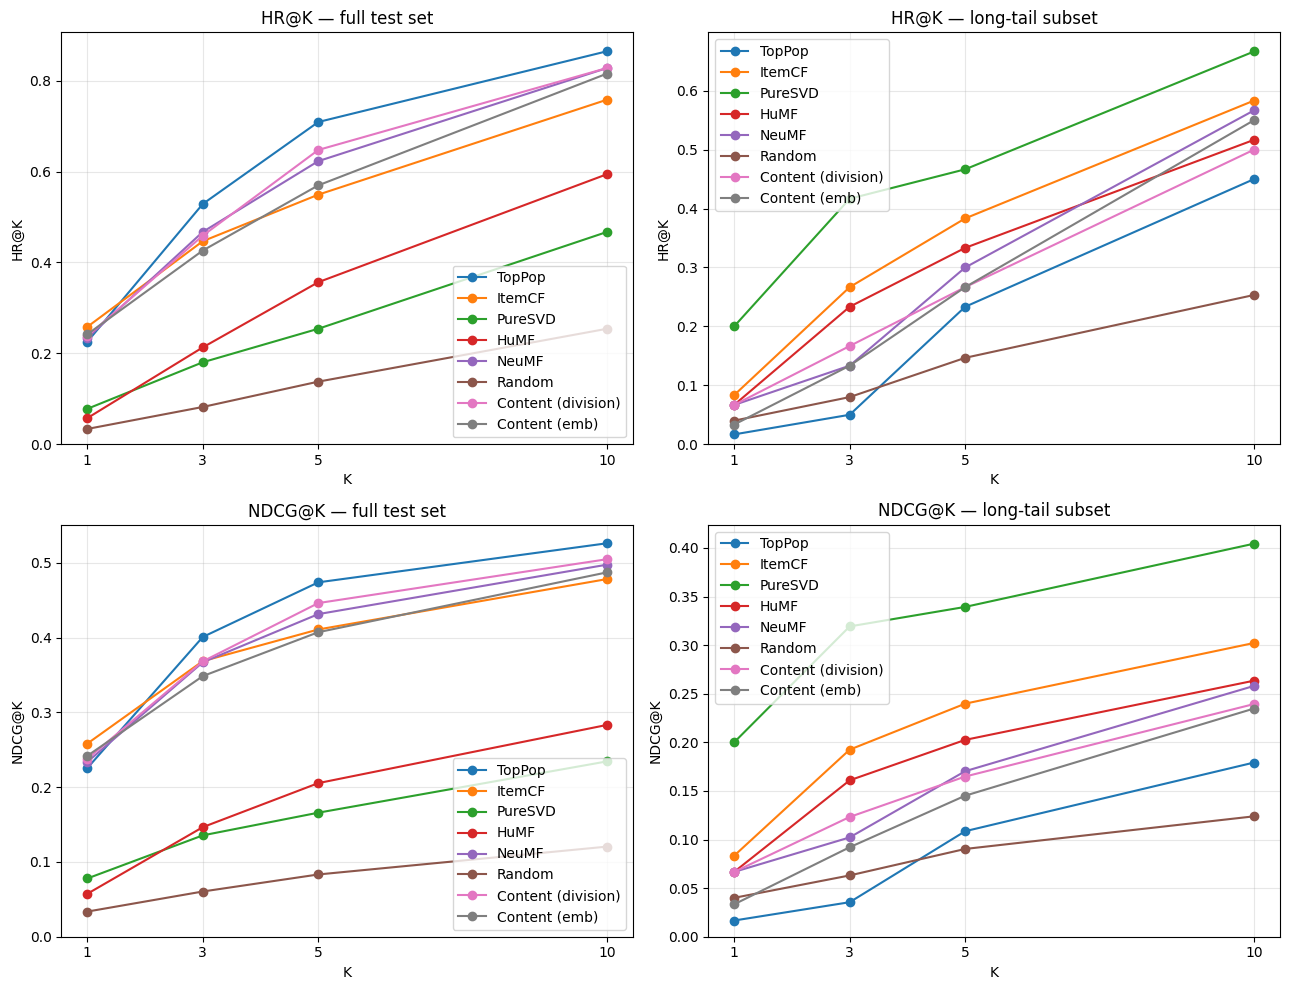

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plot_metric(summaries, 'HR',   'full',      axes[0, 0])
plot_metric(summaries, 'HR',   'long_tail', axes[0, 1])
plot_metric(summaries, 'NDCG', 'full',      axes[1, 0])
plot_metric(summaries, 'NDCG', 'long_tail', axes[1, 1])
plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [57]:
summaries

{'TopPop': {'full': {'HR@1': 0.22540983606557377,
   'NDCG@1': 0.22540983606557377,
   'HR@3': 0.5286885245901639,
   'NDCG@3': 0.4008558000124277,
   'HR@5': 0.7090163934426229,
   'NDCG@5': 0.4739122052935624,
   'HR@10': 0.8647540983606558,
   'NDCG@10': 0.5261682664006123},
  'full_n': 244,
  'long_tail': {'HR@1': 0.016666666666666666,
   'NDCG@1': 0.016666666666666666,
   'HR@3': 0.05,
   'NDCG@3': 0.03551549589285763,
   'HR@5': 0.23333333333333334,
   'NDCG@5': 0.10855747564733614,
   'HR@10': 0.45,
   'NDCG@10': 0.17919378353039217},
  'long_tail_n': 60},
 'ItemCF': {'full': {'HR@1': 0.2581967213114754,
   'NDCG@1': 0.2581967213114754,
   'HR@3': 0.44672131147540983,
   'NDCG@3': 0.3685569369145235,
   'HR@5': 0.5491803278688525,
   'NDCG@5': 0.41088757807618864,
   'HR@10': 0.7581967213114754,
   'NDCG@10': 0.4783016566969114},
  'full_n': 244,
  'long_tail': {'HR@1': 0.08333333333333333,
   'NDCG@1': 0.08333333333333333,
   'HR@3': 0.26666666666666666,
   'NDCG@3': 0.19245730